# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [1]:
import os
import subprocess
import sys
import sysconfig
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run([
            "git", "clone", "--branch", "zak-pre-experiment",
            "--single-branch", "https://github.com/abergh18/marl-tsc.git",
            str(ROOT)
        ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "eclipse-sumo"
    ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    import sumo
    os.environ["SUMO_HOME"] = sumo.SUMO_HOME
    sys.path.insert(0, os.path.join(sumo.SUMO_HOME, "tools"))

    from google.colab import userdata

    #Get access token
    token = userdata.get('GH_TOKEN')

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in Colab from /content/marl-tsc


In [2]:
if not IN_COLAB:
  %reload_ext autoreload
  %autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [3]:
import urllib.request

if IN_COLAB:
    # Create a custom opener to disguise script as a web browser
    opener = urllib.request.build_opener()
    opener.addheaders = [
        ("User-Agent", "Mozilla/5.0 (Windows NT 10.0; Win64; x64)")
    ]

    # Apply this rule globally for this notebook
    urllib.request.install_opener(opener)

In [5]:
SEED = 42
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 120_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
#network = CityNetwork(city_name="Lancaster, UK", radius=500)
network = GridNetwork(4)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=3,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: /content/marl-tsc/outputs/simulation/config.sumocfg
Traffic-light agent count: 4


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [6]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=False,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -293.66 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -291.70 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -357.66 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -314.76 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -332.58 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -318.34 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -323.47 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -325.52 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -325.46 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -284.09 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -357.26 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -341.83 | Total Steps: 7200
 Retrying in 1 seconds
[MAP

In [7]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=True,
)

 Retrying in 1 seconds
 Retrying in 1 seconds

Discovered Network Neighbours (Live TraCI):
  B1 -> ['C1', 'C2', 'B2']
  B2 -> ['C1', 'B1', 'C2']
  C1 -> ['B1', 'B2', 'C2']
  C2 -> ['C1', 'B1', 'B2']

[MAPPO] Episode 1 | Return: -313.02 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -307.67 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -338.39 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -303.59 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -290.09 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -355.46 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -306.84 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -310.49 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -296.51 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -311.42 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Ep

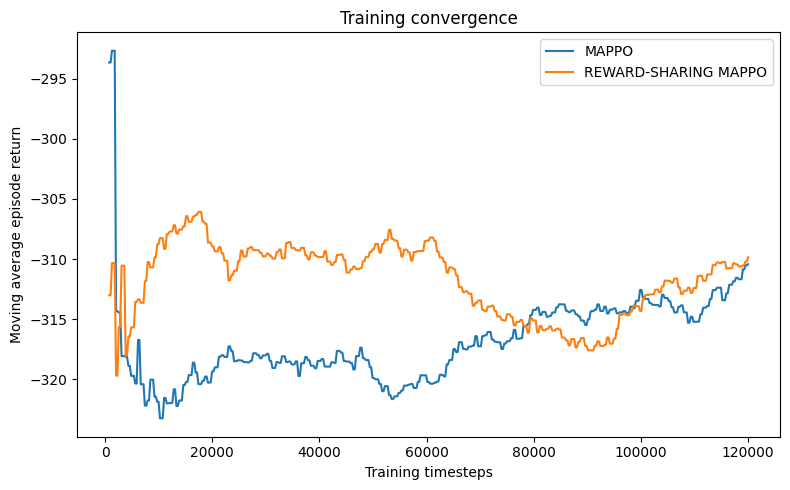

In [8]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

### 2.2. Seeded Experiments 4x4

|Seed: 0 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -282.70 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -287.85 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -288.90 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -293.23 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -347.49 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -286.21 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -298.57 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -278.50 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -301.21 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -290.48 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -316.23 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -282.50 | Total Steps: 7200
 R

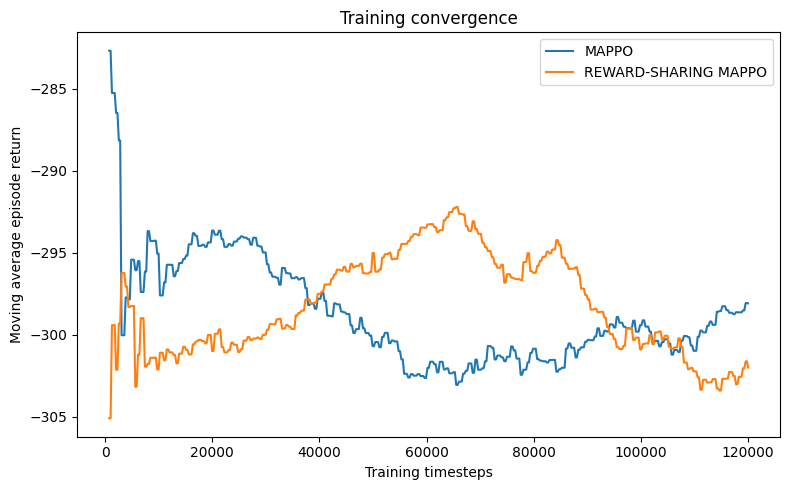

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1089.69
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1120.59
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1097.98
Evaluating Rewar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-1102.756250,0.437587,5.333333,24.706651,301.666667,1517.332393,971.333333,521.000000
3,Reward-sharing MAPPO,-820.608333,0.314670,5.666667,17.624000,291.333333,1044.198749,973.666667,650.666667


|Seed: 1 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -298.71 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -292.31 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -302.60 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -316.06 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -282.78 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -301.52 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -292.18 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -297.30 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -314.71 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -298.73 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -290.76 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -305.33 | Total Steps: 7200
 R

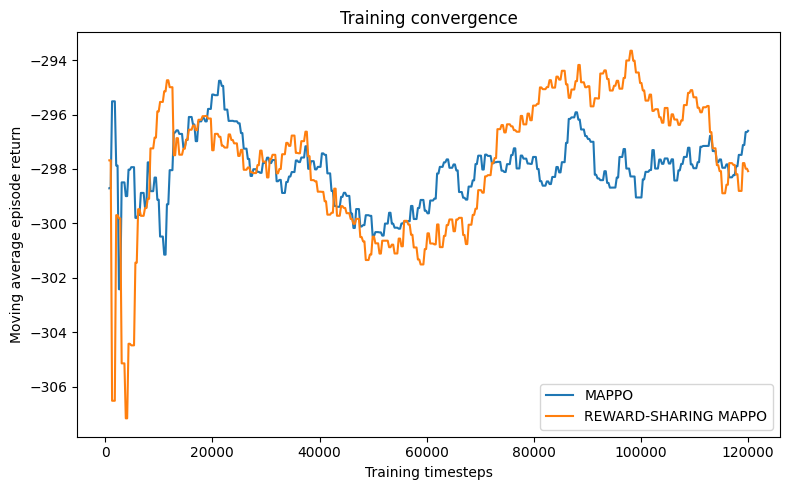

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -918.33
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -909.13
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -910.45
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-912.633333,0.354670,5.333333,20.048020,298.666667,1175.238840,970.000000,609.666667
3,Reward-sharing MAPPO,-808.775000,0.309948,6.666667,17.158392,295.000000,1009.365591,973.333333,645.666667


|Seed: 2 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -288.43 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -289.44 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -292.62 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -319.13 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -291.27 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -284.08 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -282.89 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -280.62 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -289.08 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -272.58 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -292.99 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -299.99 | Total Steps: 7200
 R

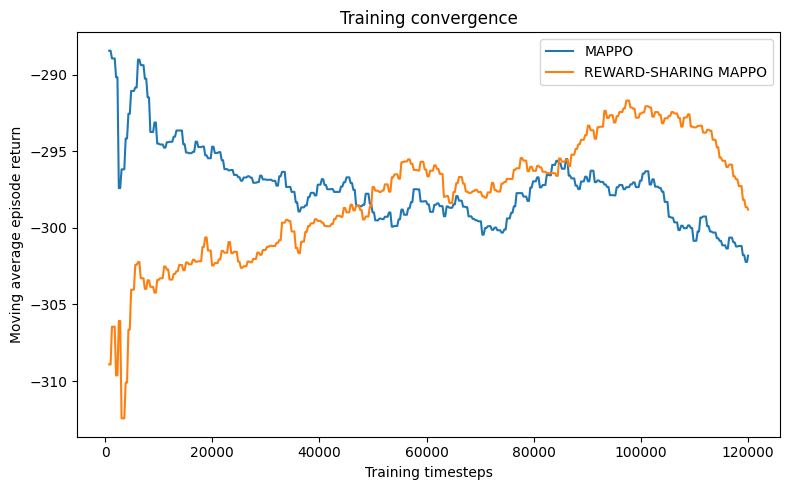

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1214.56
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1255.04
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1300.59
Evaluating Rewar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.07500,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.69375,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-1256.73125,0.504132,5.666667,27.111282,298.666667,1827.491757,967.333333,463.666667
3,Reward-sharing MAPPO,-1028.63125,0.407726,5.666667,20.477035,282.000000,1363.093927,971.666667,496.000000


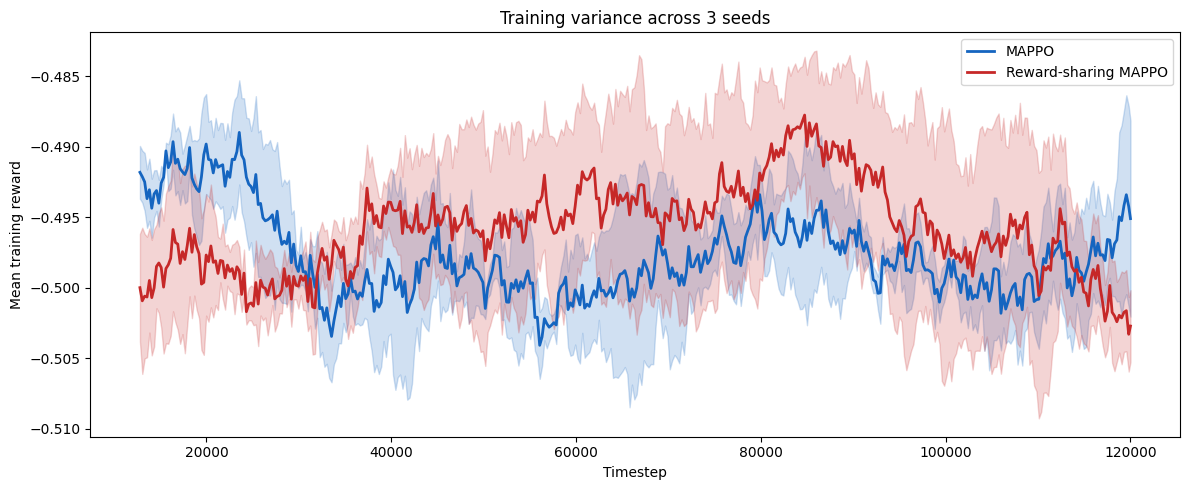

In [33]:
EXP_SWEEP = True
SEED_RANGE = 3
if EXP_SWEEP:
    from marl_tsc.exp_functions import save_history, plot_variance
    import torch

    histories_mappo = []
    histories_rs   = []
    evaluation_histories = []

    #Run experiment sweeps
    for seed in range(SEED_RANGE):
          torch.manual_seed(seed)
          print(f"|Seed: {seed} used for sweep|")

          #Run MAPPO
          mappo_model, mappo_history, mappo_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=False,
          )

          #Run reward sharing
          reward_sharing_model, reward_sharing_history, reward_sharing_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=True,
          )
          #Append and save
          histories_mappo.append(mappo_history)#accumulate in memory
          histories_rs.append(reward_sharing_history)
          save_history(mappo_history, seed, "mappo_4x4", OUTPUT_DIR)#save to as backup
          save_history(reward_sharing_history, seed, "rs_4x4", OUTPUT_DIR)

          #Display
          fig, ax = plot_training_histories({
          "MAPPO": mappo_history,
          "Reward-sharing MAPPO": reward_sharing_history,
          })
          plt.show()

          #Evaluate
          policies = {
          "Random": random_actions,
          "Fixed-Time": fixed_time_actions,
          "MAPPO": mappo_model,
          "Reward-sharing MAPPO": reward_sharing_model,
          }

          policy_results = evaluate_policies(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              policies=policies,
              episodes=EVALUATION_EPISODES,
              max_steps=EPISODE_STEPS,
              seed=SEED,
              env_kwargs=ENV_KWARGS,
          )
          evaluation_histories.append(policy_results)
          save_history(policy_results, seed, "eval", OUTPUT_DIR)

          display(evaluation_results_table(policy_results))

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax)
    plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Mean training reward")
    ax.legend()
    ax.set_title(f"Training variance across {SEED_RANGE} seeds")
    plt.tight_layout()
    plt.show()

In [34]:
import pandas as pd
import numpy as np
metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
           "mean_max_waiting_time", "mean_total_time_loss",
           "mean_arrived_vehicles_per_episode", "mean_switches_per_episode"]

rows = []
for policy_name in ["Random", "Fixed-Time", "MAPPO", "Reward-sharing MAPPO"]:
    row = {"Policy": policy_name}
    for metric in metrics:
        values = [e[policy_name][metric] for e in evaluation_histories]
        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"]  = np.std(values)
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string())

                 Policy  mean_total_reward_mean  mean_total_reward_std  mean_local_queue_mean  mean_local_queue_std  mean_waiting_time_mean  mean_waiting_time_std  mean_max_waiting_time_mean  mean_max_waiting_time_std  mean_total_time_loss_mean  mean_total_time_loss_std  mean_arrived_vehicles_per_episode_mean  mean_arrived_vehicles_per_episode_std  mean_switches_per_episode_mean  mean_switches_per_episode_std
0                Random            -1283.075000               0.000000               0.504635              0.000000               20.895747               0.000000                  244.666667                   0.000000                1708.693571                  0.000000                              966.000000                               0.000000                      713.666667                       0.000000
1            Fixed-Time            -1025.693750               0.000000               0.410573              0.000000               15.345032               0.000000            

In [38]:

# Extract metric across seeds for each policy
def perform_statisical_tests(metric, evaluation_histories, test_type):
  from scipy import stats
  mappo_grouping = [e["MAPPO"][metric] for e in evaluation_histories]
  rs_grouping   = [e["Reward-sharing MAPPO"][metric] for e in evaluation_histories]

  # Paired t-test — paired because same seed = same traffic conditions
  if test_type == "paired_t":
    _stat, p_value = stats.ttest_rel(mappo_grouping, rs_grouping)
    print(f"t={_stat:.5f}, p={p_value:.4f}")
  elif test_type == 'wilk':
    _stat, p_value = stats.wilcoxon(mappo_grouping, rs_grouping)
    print(f"W={_stat:.5f}, p={p_value:.4f}")
  else:
    raise ValueError(f"Unknown test type: {test_type}")

  return _stat

perform_statisical_tests("mean_local_queue", evaluation_histories, "wilk")

W=0.00000, p=0.2500


np.float64(0.0)

In [39]:
evaluation_histories

[{'Random': {'policy_name': 'random_actions',
   'episodes': 3,
   'mean_total_reward': -1283.0750000000007,
   'mean_local_queue': 0.5046354166666667,
   'mean_max_queue': 8.333333333333334,
   'total_completed_steps': 1800,
   'mean_switches_per_episode': 713.6666666666666,
   'mean_arrived_vehicles_per_episode': 966.0,
   'mean_waiting_time': 20.895747054872313,
   'mean_max_waiting_time': 244.66666666666666,
   'mean_total_time_loss': 1708.6935712597824,
   'mean_vehicle_count': 31.03333333333333,
   'episode_details': [{'episode': 1,
     'total_reward': -1202.9125000000026,
     'mean_local_queue': 0.47140625,
     'max_queue': 7.0,
     'switches': 711,
     'arrived_vehicles': 965,
     'mean_waiting_time': 18.094142390227205,
     'max_waiting_time': 203.0,
     'mean_total_time_loss': 1454.6179953479143,
     'mean_vehicle_count': 29.816666666666666,
     'completed_steps': 600},
    {'episode': 2,
     'total_reward': -1310.881250000001,
     'mean_local_queue': 0.5160416666

## 3. Export a SUMO replay

In [9]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

 Retrying in 1 seconds
 Retrying in 1 seconds
Open this file in the SUMO GUI: /content/marl-tsc/outputs/replays/reward_sharing_mappo/replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [10]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1446.85
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1238.53
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1270.09
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1052.29
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1048.72
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1048.22
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -763.25
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -761.39
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -776.88
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1318.487500,0.519288,9.333333,20.087736,255.666667,1731.873176,981.333333,716.333333
1,Fixed-Time,-1049.745833,0.420642,6.333333,14.469897,88.333333,1113.624539,985.666667,396.000000
2,MAPPO,-767.172917,0.294375,4.333333,13.212911,290.000000,890.524930,986.000000,602.666667
3,Reward-sharing MAPPO,-688.897917,0.259097,5.000000,11.825998,299.666667,783.664831,989.000000,667.000000


In [40]:
!git status
#!git add .
commit = False
if commit:
  import shlex
  commit_msg = '''
  File for functions for use with seeded experiments added
  '''
  !git config --global user.email user_email
  !git config --global user.name 'IsaacFayle-Waters'
  !git commit -m {shlex.quote(commit_msg)}

On branch zak-pre-experiment
Your branch is up to date with 'origin/zak-pre-experiment'.

nothing to commit, working tree clean


In [14]:
!git remote set-url origin https://{token}@github.com/abergh18/marl-tsc.git
!git push -u origin zak-pre-experiment

Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (5/5), 965 bytes | 965.00 KiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/abergh18/marl-tsc.git
   03eb5e6..38c08f0  zak-pre-experiment -> zak-pre-experiment
Branch 'zak-pre-experiment' set up to track remote branch 'zak-pre-experiment' from 'origin'.


In [13]:
import inspect
print(inspect.signature(mappo_model.act))
print(inspect.getsource(mappo_model.act))

(observations: 'dict[str, np.ndarray]', infos: 'dict[str, dict] | None' = None, deterministic: 'bool' = True) -> 'dict[str, list[int] | int]'
    def act(
        self,
        observations: dict[str, np.ndarray],
        infos: dict[str, dict] | None = None,
        deterministic: bool = True,
    ) -> dict[str, list[int] | int]:
        actions: dict[str, list[int] | int] = {}
        active_agents = list(observations.keys())
        
        for agent_id in active_agents:
            mask = None
            if infos is not None:
                info = infos.get(agent_id) or {}
                mask = info.get("action_mask")
                
            try:
                agent_index = self.traffic_light_ids.index(agent_id)
            except ValueError:
                agent_index = 0
                
            actions[agent_id] = self._act_single(
                observations[agent_id],
                mask=mask,
                deterministic=deterministic,
                agent

In [14]:
import torch

# Create a dummy observation matching the model's expected input
# obs_dim=18, actor_obs_dim=27 for 9 agents
dummy_obs = {
    agent: torch.zeros(18).numpy()
    for agent in mappo_model.traffic_light_ids
}

with torch.no_grad():
    base_actions = mappo_model.act(dummy_obs, deterministic=True)
    rs_actions   = reward_sharing_model.act(dummy_obs, deterministic=True)

print("Base actions:", base_actions)
print("RS actions:  ", rs_actions)
print("All zero (base):", all(v == 0 for v in base_actions.values()))
print("All zero (rs):  ", all(v == 0 for v in rs_actions.values()))
print("Actions match:  ", base_actions == rs_actions)

Base actions: {'B1': 0, 'B2': 0, 'C1': 0, 'C2': 0}
RS actions:   {'B1': [0, 2], 'B2': [0, 2], 'C1': [0, 2], 'C2': [0, 2]}
All zero (base): True
All zero (rs):   False
Actions match:   False
